# Run_Training notebook: Flex at 32x32 on PSD glossy-to-difference pairs

This notebook follows the same training recipe as the current PSD `Flex32` notebook, but changes the target.

Setup in this notebook:
- `Backbone.Flex`
- `32x32`
- conditioning = glossy/specular RGB image
- target = `glossy - diffuse`
- train split = `PSD_Train`
- periodic evaluation split = `PSD_val`
- DDPM-style periodic evaluation every `200` epochs

The evaluation figure adds an extra reconstruction row:
- true reconstructed diffuse = `glossy - true_difference`
- predicted reconstructed diffuse = `glossy - predicted_difference`


In [1]:
from __future__ import annotations

import math
import os
import random
import sys
from collections import OrderedDict
from contextlib import contextmanager
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm


def resolve_repo_root() -> Path:
    candidates = [Path.cwd(), Path.cwd() / 'FoilDIff', Path.cwd().parent / 'FoilDIff']
    for candidate in candidates:
        if (candidate / 'Run_Training.py').exists() and (candidate / 'Backbone.py').exists():
            return candidate.resolve()
    raise FileNotFoundError('Could not locate the FoilDIff repo root from the current working directory.')


REPO_ROOT = resolve_repo_root()
os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import Backbone
import Diffuser as diff

print(f'repo root: {REPO_ROOT}')


/Users/27171653/Library/Python/3.12/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


repo root: /Users/27171653/Desktop/untitled folder/FoilDIff


In [2]:
SEED = 42
IMAGE_SIZE = 32
BATCH_SIZE = 10
NOISE_STEPS = 200
EPOCHS = 2000
LR = 1e-4
EMA_DECAY = 0.9999
TRAIN_TYPE = 'e'
EVAL_EVERY = 200
CHECKPOINT_EVERY = 500
VAL_CASE_INDEX = 0
VAL_BATCHES = 4
EVAL_SEED = 123

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

DEFAULT_PSD_ROOT = Path('/Users/27171653/Desktop/PhD/Highlight-modelling/PSD_Dataset/PSD_Dataset')
PSD_ROOT = Path(os.environ.get('PSD_DATASET_ROOT', str(DEFAULT_PSD_ROOT))).expanduser()

TRAIN_DIFFUSE_DIR = PSD_ROOT / 'PSD_Train' / 'PSD_Train_diffuse'
TRAIN_GLOSSY_DIR = PSD_ROOT / 'PSD_Train' / 'PSD_Train_specular'
VAL_DIFFUSE_DIR = PSD_ROOT / 'PSD_val' / 'PSD_val_diffuse'
VAL_GLOSSY_DIR = PSD_ROOT / 'PSD_val' / 'PSD_val_specular'

TRAINER_SAVE_PATH = './checkpoints/psd_difference_model_checkpoint'
MODEL_DIR = REPO_ROOT / 'models' / '32'
MODEL_DIR.mkdir(parents=True, exist_ok=True)


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)


@contextmanager
def temporary_seed(seed: int):
    cpu_state = torch.get_rng_state()
    np_state = np.random.get_state()
    py_state = random.getstate()
    cuda_states = None
    if torch.cuda.is_available():
        cuda_states = torch.cuda.get_rng_state_all()
    set_seed(seed)
    try:
        yield
    finally:
        torch.set_rng_state(cpu_state)
        np.random.set_state(np_state)
        random.setstate(py_state)
        if cuda_states is not None:
            torch.cuda.set_rng_state_all(cuda_states)


set_seed(SEED)
print(f'device: {DEVICE}')
print(f'PSD root: {PSD_ROOT}')


device: cpu
PSD root: /Users/27171653/Desktop/PhD/Highlight-modelling/PSD_Dataset/PSD_Dataset


In [3]:
VALID_EXTS = {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff', '.webp'}
PIL_BILINEAR = getattr(Image, 'Resampling', Image).BILINEAR


class PairedPSDDifferenceDataset(Dataset):
    def __init__(self, glossy_dir: Path, diffuse_dir: Path, image_size: int = 32):
        self.glossy_dir = Path(glossy_dir)
        self.diffuse_dir = Path(diffuse_dir)
        self.image_size = int(image_size)

        if not self.glossy_dir.exists() or not self.diffuse_dir.exists():
            raise FileNotFoundError(
                f'Could not find paired PSD directories: {self.glossy_dir} and {self.diffuse_dir}'
            )

        glossy_files = {p.name: p for p in self.glossy_dir.iterdir() if p.suffix.lower() in VALID_EXTS}
        diffuse_files = {p.name: p for p in self.diffuse_dir.iterdir() if p.suffix.lower() in VALID_EXTS}
        common_names = sorted(set(glossy_files.keys()) & set(diffuse_files.keys()))
        if not common_names:
            raise ValueError(
                f'No matching glossy/diffuse filenames were found in {self.glossy_dir} and {self.diffuse_dir}'
            )

        self.samples = [
            {
                'name': name,
                'glossy_path': glossy_files[name],
                'diffuse_path': diffuse_files[name],
            }
            for name in common_names
        ]

    def __len__(self) -> int:
        return len(self.samples)

    def _load_rgb_tensor(self, path: Path) -> torch.Tensor:
        image = Image.open(path).convert('RGB')
        image = image.resize((self.image_size, self.image_size), resample=PIL_BILINEAR)
        array = np.asarray(image, dtype=np.float32) / 255.0
        return torch.from_numpy(array).permute(2, 0, 1).contiguous()

    def __getitem__(self, idx: int):
        sample = self.samples[idx]
        glossy = self._load_rgb_tensor(sample['glossy_path'])
        diffuse = self._load_rgb_tensor(sample['diffuse_path'])
        difference = glossy - diffuse
        meta = {
            'name': sample['name'],
            'glossy_path': str(sample['glossy_path']),
            'diffuse_path': str(sample['diffuse_path']),
        }
        return glossy, difference, diffuse, meta


train_dataset = PairedPSDDifferenceDataset(TRAIN_GLOSSY_DIR, TRAIN_DIFFUSE_DIR, image_size=IMAGE_SIZE)
val_dataset = PairedPSDDifferenceDataset(VAL_GLOSSY_DIR, VAL_DIFFUSE_DIR, image_size=IMAGE_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

fixed_val_condition_cpu, fixed_val_target_cpu, fixed_val_diffuse_cpu, fixed_val_meta = val_dataset[VAL_CASE_INDEX]
fixed_val_condition = fixed_val_condition_cpu.unsqueeze(0).to(DEVICE)
fixed_val_target = fixed_val_target_cpu.unsqueeze(0).to(DEVICE)
fixed_val_diffuse = fixed_val_diffuse_cpu.unsqueeze(0).to(DEVICE)

print(f'train dataset size: {len(train_dataset)}')
print(f'val dataset size: {len(val_dataset)}')
print(f'train batches per epoch: {len(train_loader)}')
print(f'fixed val case: {fixed_val_meta["name"]}')
print('fixed condition shape:', tuple(fixed_val_condition.shape))
print('fixed difference target shape:', tuple(fixed_val_target.shape))
print('fixed diffuse shape:', tuple(fixed_val_diffuse.shape))


train dataset size: 361
val dataset size: 807
train batches per epoch: 36
fixed val case: Val_0001.png
fixed condition shape: (1, 3, 32, 32)
fixed difference target shape: (1, 3, 32, 32)
fixed diffuse shape: (1, 3, 32, 32)


In [4]:
def get_cosine_lambda(initial_lr: float, final_lr: float, epochs: int, warmup_epoch: int):
    def cosine_lambda(idx_epoch: int) -> float:
        if idx_epoch < warmup_epoch:
            return idx_epoch / warmup_epoch
        return 1 - (1 - (math.cos((idx_epoch - warmup_epoch) / (epochs - warmup_epoch) * math.pi) + 1) / 2) * (1 - final_lr / initial_lr)

    return cosine_lambda


def checkpoint_save(model: torch.nn.Module, loss: float, l_epoch: int, save_path: str, parameterization: str = 'e') -> None:
    base_dir = os.path.dirname(save_path)
    os.makedirs(base_dir, exist_ok=True)

    loss_file = os.path.join(base_dir, 'loss.csv')
    with open(loss_file, 'a') as f:
        f.write(f'{l_epoch},{loss:.6f}\n')

    model_name = model.__class__.__name__
    model_dir = os.path.join(base_dir, f'{model_name}_epoch_{l_epoch}_TParam_{parameterization}_loss_{loss:.4f}')
    os.makedirs(model_dir, exist_ok=True)

    checkpoint_file = os.path.join(model_dir, 'model.pth')
    torch.save(model.state_dict(), checkpoint_file)
    print(f'model checkpoint saved to {checkpoint_file}')

    arch_file = os.path.join(model_dir, 'architecture.txt')
    with open(arch_file, 'w') as f:
        f.write(str(model))


def update_ema(ema_model: torch.nn.Module, model: torch.nn.Module, decay: float = 0.999) -> None:
    ema_params = OrderedDict(ema_model.named_parameters())
    model_params = OrderedDict(model.named_parameters())
    for name, param in model_params.items():
        if name in ema_params:
            ema_params[name].data.mul_(decay).add_(param.data, alpha=1 - decay)


In [5]:
model = Backbone.Flex(size=IMAGE_SIZE, noise_steps=NOISE_STEPS).to(DEVICE)
ema_model = deepcopy(model).to(DEVICE)
ema_model.eval()

diffuser = diff.CosSchDiffuser(steps=NOISE_STEPS, device=DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer,
    get_cosine_lambda(initial_lr=LR, final_lr=1e-5, epochs=EPOCHS, warmup_epoch=100),
)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'model: {model.__class__.__name__}')
print(f'trainable parameters: {trainable_params:,}')
print(f'optimizer: {optimizer.__class__.__name__}(lr={LR})')
print(f'diffuser: {diffuser.name}, steps={diffuser.steps}')


model: UNetWithTransformer
trainable parameters: 24,365,379
optimizer: AdamW(lr=0.0001)
diffuser: CosSchDiffuser, steps=200


In [6]:
def train_step(model: torch.nn.Module, batch, diffuser: diff.Diffuser, device: torch.device, train_type: str = 'e') -> torch.Tensor:
    condition, targets, _diffuse, _meta = batch
    condition = condition.float().to(device)
    targets = targets.float().to(device)

    batch_size = condition.size(0)
    t = torch.randint(0, diffuser.steps, (batch_size,), dtype=torch.long, device=device)
    noise = torch.randn_like(targets)

    if train_type == 'e':
        noisy_xt = diffuser.forward_diffusion(targets, t, noise)
        prediction = model(noisy_xt, t, condition)
        loss = F.mse_loss(prediction, noise)
    elif train_type == 'x':
        noisy_xt = diffuser.forward_diffusion(targets, t, noise)
        prediction = model(noisy_xt, t, condition)
        loss = F.mse_loss(prediction, targets)
    elif train_type == 'v':
        velocity = diffuser.calculate_velocity(targets, t, noise)
        prediction = model(velocity, t, condition)
        loss = F.mse_loss(prediction, velocity)
    else:
        raise ValueError(f'Unknown training type: {train_type}')

    del batch, condition, targets
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return loss


def evaluate_noise_loss(model: torch.nn.Module, loader: DataLoader, diffuser: diff.Diffuser, device: torch.device, num_batches: int = 4) -> float:
    was_training = model.training
    model.eval()
    losses = []
    with torch.no_grad():
        for idx, batch in enumerate(loader):
            if idx >= num_batches:
                break
            losses.append(float(train_step(model, batch, diffuser, device, train_type=TRAIN_TYPE).item()))
    if was_training:
        model.train()
    return float(sum(losses) / len(losses)) if losses else float('nan')


def ddpm_sample_from_noise_safe(model: torch.nn.Module, diffuser: diff.Diffuser, condition: torch.Tensor, show_progress: bool = False) -> torch.Tensor:
    with torch.no_grad():
        x_t = torch.randn_like(condition)
        t_now = torch.full((x_t.shape[0],), diffuser.steps - 1, device=condition.device, dtype=torch.long)
        iterator = range(diffuser.steps - 1)
        if show_progress:
            iterator = tqdm(iterator, desc='DDPM eval sampling', leave=False)
        for _ in iterator:
            t_pre = torch.clamp(t_now - 1, min=0)
            predicted_noise = model(x_t, t_now, condition)
            x_t = diffuser.DDPM_sample_step(x_t, t_now, t_pre, predicted_noise)
            t_now = t_pre
        return x_t


def channel_limits(array: np.ndarray) -> tuple[float, float]:
    vmin = float(array.min())
    vmax = float(array.max())
    if vmin == vmax:
        eps = 1e-6 if vmin == 0 else abs(vmin) * 1e-6
        vmin -= eps
        vmax += eps
    return vmin, vmax


def normalize_rgb(array: np.ndarray, vmin: float, vmax: float) -> np.ndarray:
    rgb = np.transpose(array, (1, 2, 0))
    if vmax == vmin:
        return np.zeros_like(rgb)
    return np.clip((rgb - vmin) / (vmax - vmin), 0.0, 1.0)


def plot_prediction(
    target_tensor: torch.Tensor,
    prediction_tensor: torch.Tensor,
    condition_tensor: torch.Tensor,
    true_diffuse_tensor: torch.Tensor,
    epoch: int,
) -> None:
    target_np = target_tensor[0].detach().cpu().numpy()
    prediction_np = prediction_tensor[0].detach().cpu().numpy()
    condition_np = condition_tensor[0].detach().cpu().numpy()
    true_diffuse_np = true_diffuse_tensor[0].detach().cpu().numpy()
    error_np = np.abs(prediction_np - target_np)
    channel_names = ['Red', 'Green', 'Blue']

    diff_vmin = float(min(target_np.min(), prediction_np.min()))
    diff_vmax = float(max(target_np.max(), prediction_np.max()))
    target_rgb = normalize_rgb(target_np, diff_vmin, diff_vmax)
    prediction_rgb = normalize_rgb(prediction_np, diff_vmin, diff_vmax)
    error_rgb = error_np.mean(axis=0)
    error_rgb_vmin, error_rgb_vmax = channel_limits(error_rgb)

    true_reconstructed_diffuse = np.clip(np.transpose(condition_np - target_np, (1, 2, 0)), 0.0, 1.0)
    predicted_reconstructed_diffuse = np.clip(np.transpose(condition_np - prediction_np, (1, 2, 0)), 0.0, 1.0)
    true_diffuse_rgb = np.clip(np.transpose(true_diffuse_np, (1, 2, 0)), 0.0, 1.0)
    reconstruction_error = np.abs(predicted_reconstructed_diffuse - true_diffuse_rgb).mean(axis=2)
    recon_err_vmin, recon_err_vmax = channel_limits(reconstruction_error)

    fig, axes = plt.subplots(5, 3, figsize=(12, 18))
    fig.suptitle(f'Fixed validation inference at epoch {epoch}', fontsize=16)

    for row, name in enumerate(channel_names):
        target_vmin, target_vmax = channel_limits(target_np[row])
        pred_vmin, pred_vmax = channel_limits(prediction_np[row])
        err_vmin, err_vmax = channel_limits(error_np[row])

        axes[row, 0].imshow(target_np[row], cmap='coolwarm', vmin=target_vmin, vmax=target_vmax)
        axes[row, 0].set_title(f'{name} difference target')
        axes[row, 1].imshow(prediction_np[row], cmap='coolwarm', vmin=pred_vmin, vmax=pred_vmax)
        axes[row, 1].set_title(f'{name} difference prediction')
        axes[row, 2].imshow(error_np[row], cmap='magma', vmin=err_vmin, vmax=err_vmax)
        axes[row, 2].set_title(f'{name} abs error')
        for col in range(3):
            axes[row, col].axis('off')

    axes[3, 0].imshow(target_rgb)
    axes[3, 0].set_title('RGB difference target')
    axes[3, 1].imshow(prediction_rgb)
    axes[3, 1].set_title('RGB difference prediction')
    axes[3, 2].imshow(error_rgb, cmap='magma', vmin=error_rgb_vmin, vmax=error_rgb_vmax)
    axes[3, 2].set_title('RGB mean abs error')
    for col in range(3):
        axes[3, col].axis('off')

    axes[4, 0].imshow(true_reconstructed_diffuse)
    axes[4, 0].set_title('True reconstructed diffuse')
    axes[4, 1].imshow(predicted_reconstructed_diffuse)
    axes[4, 1].set_title('Predicted reconstructed diffuse')
    axes[4, 2].imshow(reconstruction_error, cmap='magma', vmin=recon_err_vmin, vmax=recon_err_vmax)
    axes[4, 2].set_title('Reconstructed diffuse abs error')
    for col in range(3):
        axes[4, col].axis('off')

    plt.tight_layout()
    plt.show()


def run_eval(
    model: torch.nn.Module,
    diffuser: diff.Diffuser,
    val_loader: DataLoader,
    condition: torch.Tensor,
    target: torch.Tensor,
    true_diffuse: torch.Tensor,
    epoch: int,
) -> dict:
    was_training = model.training
    model.eval()
    val_noise_loss = evaluate_noise_loss(model, val_loader, diffuser, DEVICE, num_batches=VAL_BATCHES)
    with temporary_seed(EVAL_SEED):
        prediction = ddpm_sample_from_noise_safe(model, diffuser, condition, show_progress=False)
    sample_mse = float(F.mse_loss(prediction, target).item())
    sample_mae = float(F.l1_loss(prediction, target).item())
    reconstructed_diffuse = condition - prediction
    reconstructed_diffuse_mse = float(F.mse_loss(reconstructed_diffuse, true_diffuse).item())
    reconstructed_diffuse_mae = float(F.l1_loss(reconstructed_diffuse, true_diffuse).item())
    if was_training:
        model.train()
    plot_prediction(target, prediction, condition, true_diffuse, epoch)
    return {
        'epoch': epoch,
        'val_noise_loss': val_noise_loss,
        'sample_mse': sample_mse,
        'sample_mae': sample_mae,
        'reconstructed_diffuse_mse': reconstructed_diffuse_mse,
        'reconstructed_diffuse_mae': reconstructed_diffuse_mae,
    }


Training:  10%|█         | 7200/72000 [55:45<8:52:17,  2.03it/s, loss=0.0119, lr=9.94e-5] 

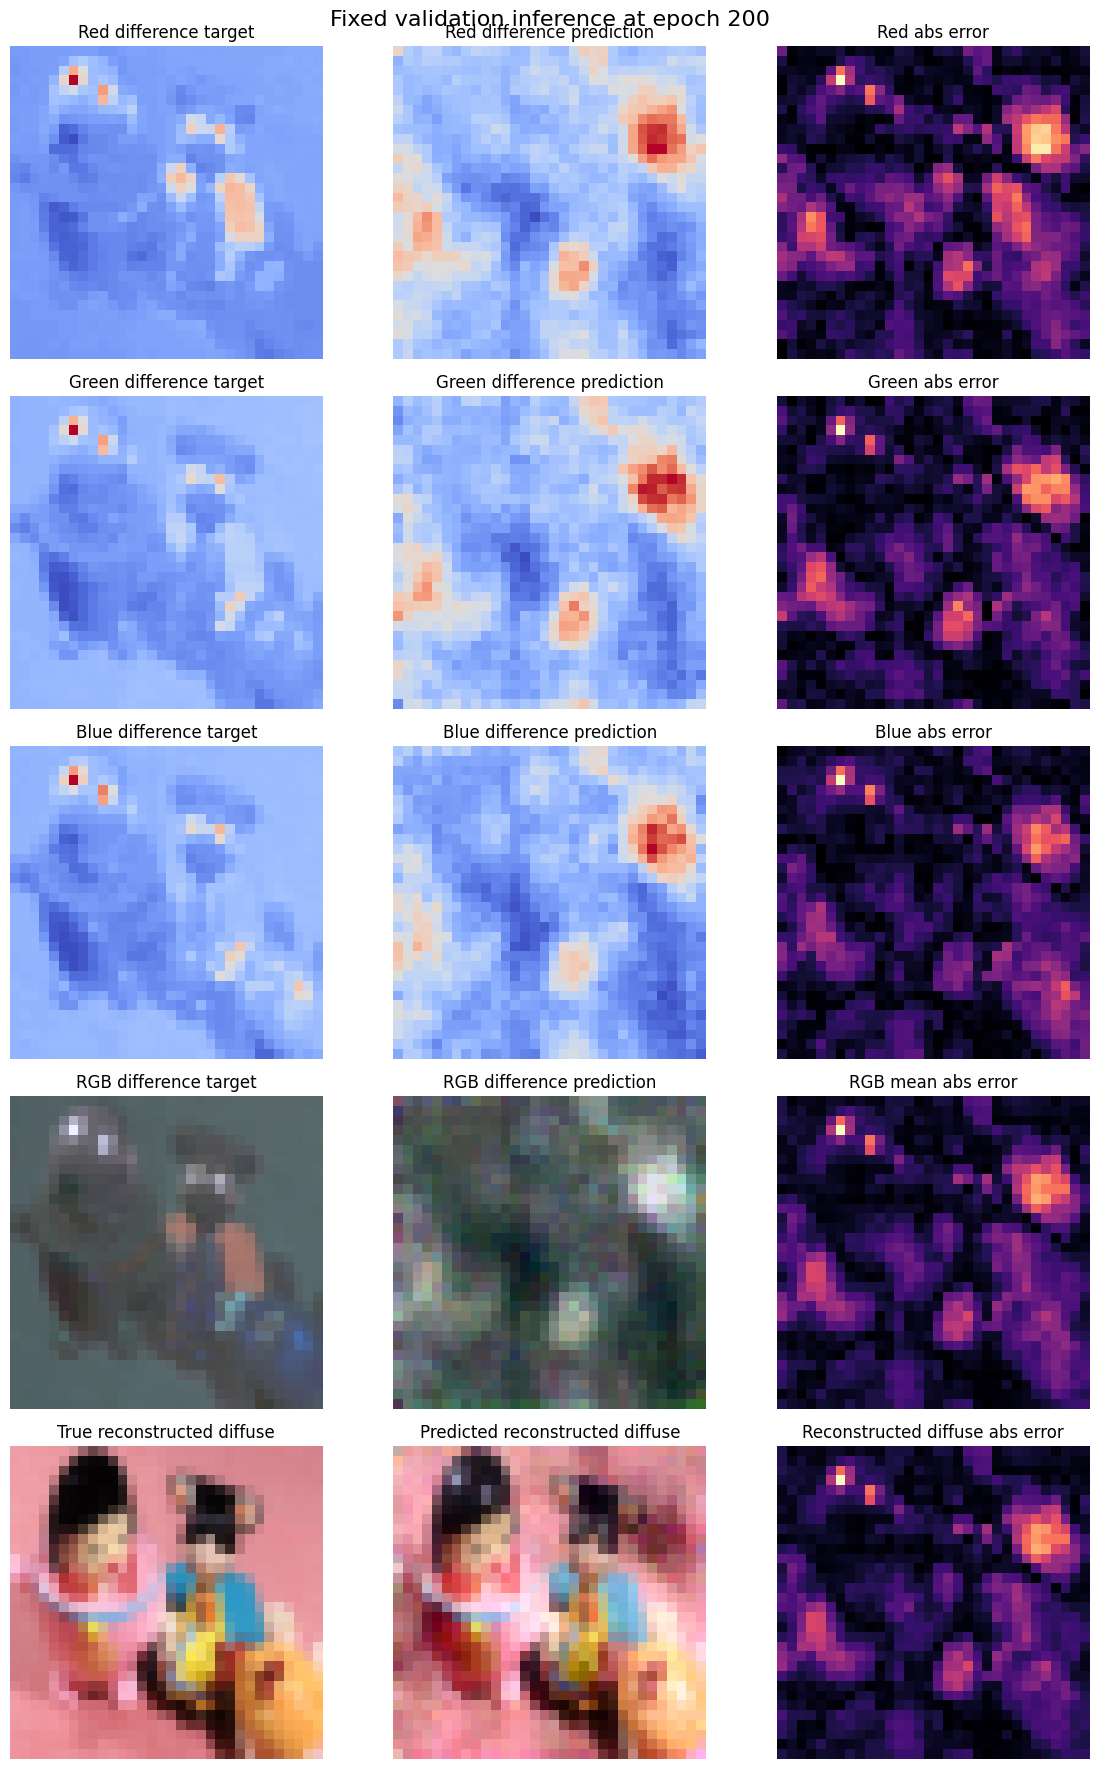

epoch  200 | train_loss=0.019354 | val_noise_loss=0.038002 | diff_mse=0.014523 | recon_diffuse_mse=0.014523


Training:  10%|█         | 7289/72000 [56:36<8:53:36,  2.02it/s, loss=0.0153, lr=9.94e-5] 

KeyboardInterrupt: 

In [7]:
progress_bar = tqdm(total=EPOCHS * len(train_loader), desc='Training', dynamic_ncols=True)
loss_history = []
eval_history = []

model.train()
for epoch in range(EPOCHS):
    epoch_loss = 0.0

    for batch in train_loader:
        optimizer.zero_grad()
        loss = train_step(model, batch, diffuser, DEVICE, train_type=TRAIN_TYPE)
        loss.backward()
        optimizer.step()
        update_ema(ema_model, model, decay=EMA_DECAY)

        epoch_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item(), lr=optimizer.param_groups[0]['lr'])
        progress_bar.update(1)

        del batch, loss
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    epoch_loss /= len(train_loader)
    loss_history.append(epoch_loss)
    scheduler.step()

    epoch_idx = epoch + 1

    if epoch_idx % CHECKPOINT_EVERY == 0:
        checkpoint_save(model, loss_history[-1], epoch_idx, TRAINER_SAVE_PATH, parameterization=TRAIN_TYPE)

    if epoch_idx % EVAL_EVERY == 0:
        result = run_eval(
            model,
            diffuser,
            val_loader,
            fixed_val_condition,
            fixed_val_target,
            fixed_val_diffuse,
            epoch_idx,
        )
        eval_history.append(result)
        print(
            f'epoch {epoch_idx:4d} | train_loss={epoch_loss:.6f} | '
            f'val_noise_loss={result["val_noise_loss"]:.6f} | '
            f'diff_mse={result["sample_mse"]:.6f} | '
            f'recon_diffuse_mse={result["reconstructed_diffuse_mse"]:.6f}'
        )

progress_bar.close()
print('training complete.')
checkpoint_save(model, loss_history[-1], EPOCHS, TRAINER_SAVE_PATH, parameterization=TRAIN_TYPE)

final_model_path = MODEL_DIR / f'PSD_Difference_{model.__class__.__name__}.pth'
torch.save(
    {
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
    },
    final_model_path,
)
print(f'model saved to {final_model_path}')


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, len(loss_history) + 1), loss_history)
axes[0].set_title('Train loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].grid(True)

if eval_history:
    epochs = [entry['epoch'] for entry in eval_history]
    val_noise_loss = [entry['val_noise_loss'] for entry in eval_history]
    reconstructed_diffuse_mse = [entry['reconstructed_diffuse_mse'] for entry in eval_history]
    axes[1].plot(epochs, val_noise_loss, marker='o', label='val noise loss')
    axes[1].plot(epochs, reconstructed_diffuse_mse, marker='s', label='reconstructed diffuse mse')
    axes[1].set_title('Periodic eval metrics')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Metric value')
    axes[1].grid(True)
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, 'No eval history yet', ha='center', va='center')
    axes[1].axis('off')

plt.tight_layout()
plt.show()

eval_history


In [ ]:
TEST_GLOSSY_DIR = PSD_ROOT / 'PSD_Test' / 'PSD_Test_specular'
TEST_DIFFUSE_DIR = PSD_ROOT / 'PSD_Test' / 'PSD_Test_diffuse'
TEST_BATCH_SIZE = 1
TEST_EVAL_SEED = 123

try:
    from skimage.metrics import structural_similarity as structural_similarity
except ImportError:
    structural_similarity = None


class PSDTestMetricsDataset(Dataset):
    def __init__(self, glossy_dir: Path, diffuse_dir: Path, image_size: int):
        self.glossy_dir = Path(glossy_dir)
        self.diffuse_dir = Path(diffuse_dir)
        glossy_files = {path.name: path for path in self.glossy_dir.iterdir() if path.suffix.lower() in VALID_EXTS}
        diffuse_files = {path.name: path for path in self.diffuse_dir.iterdir() if path.suffix.lower() in VALID_EXTS}
        self.names = sorted(set(glossy_files) & set(diffuse_files))
        if not self.names:
            raise RuntimeError(f'No PSD test pairs found in {self.glossy_dir} and {self.diffuse_dir}')
        self.glossy_files = glossy_files
        self.diffuse_files = diffuse_files
        self.image_size = image_size

    def __len__(self) -> int:
        return len(self.names)

    def __getitem__(self, idx: int):
        name = self.names[idx]
        glossy = load_rgb_tensor(self.glossy_files[name], self.image_size)
        diffuse = load_rgb_tensor(self.diffuse_files[name], self.image_size)
        return glossy, diffuse, name


def compute_batch_psnr(prediction: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    mse = F.mse_loss(prediction, target, reduction='none').flatten(1).mean(dim=1)
    return 10.0 * torch.log10(1.0 / mse.clamp_min(1e-10))


def compute_batch_ssim(prediction: torch.Tensor, target: torch.Tensor) -> list[float]:
    if structural_similarity is None:
        return []
    scores = []
    for pred_img, true_img in zip(prediction, target):
        pred_np = pred_img.detach().cpu().permute(1, 2, 0).numpy()
        true_np = true_img.detach().cpu().permute(1, 2, 0).numpy()
        scores.append(float(structural_similarity(true_np, pred_np, channel_axis=-1, data_range=1.0)))
    return scores


if not TEST_GLOSSY_DIR.exists() or not TEST_DIFFUSE_DIR.exists():
    raise FileNotFoundError(f'Missing PSD test directories: {TEST_GLOSSY_DIR} and/or {TEST_DIFFUSE_DIR}')

test_dataset = PSDTestMetricsDataset(TEST_GLOSSY_DIR, TEST_DIFFUSE_DIR, image_size=IMAGE_SIZE)
test_loader = DataLoader(test_dataset, batch_size=TEST_BATCH_SIZE, shuffle=False, num_workers=0)
eval_model = ema_model if 'ema_model' in globals() else model
predicts_difference = 'fixed_val_diffuse' in globals()

torch.manual_seed(TEST_EVAL_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(TEST_EVAL_SEED)
test_noise_generator = torch.Generator()
test_noise_generator.manual_seed(TEST_EVAL_SEED)

psnr_scores = []
ssim_scores = []
test_rows = []

eval_model.eval()
with torch.no_grad():
    for condition, true_diffuse, names in tqdm(test_loader, desc='PSD test metrics'):
        condition = condition.to(DEVICE)
        true_diffuse = true_diffuse.to(DEVICE)

        if 'ddpm_sample_from_noise_safe' in globals():
            raw_prediction = ddpm_sample_from_noise_safe(eval_model, diffuser, condition, show_progress=False)
        else:
            init_noise = torch.randn(true_diffuse.shape, generator=test_noise_generator, dtype=true_diffuse.dtype).to(DEVICE)
            raw_prediction = diffuser.sample_from_noise(
                eval_model,
                condition,
                parameterization=TRAIN_TYPE,
                show_progress=False,
                initial_noise=init_noise,
            )

        predicted_diffuse = (condition - raw_prediction).clamp(0.0, 1.0) if predicts_difference else raw_prediction.clamp(0.0, 1.0)
        batch_psnr = compute_batch_psnr(predicted_diffuse, true_diffuse)
        batch_ssim = compute_batch_ssim(predicted_diffuse, true_diffuse)

        for idx, name in enumerate(names):
            row = {'name': name, 'psnr': float(batch_psnr[idx].item())}
            if batch_ssim:
                row['ssim'] = float(batch_ssim[idx])
            test_rows.append(row)
            psnr_scores.append(row['psnr'])
            if 'ssim' in row:
                ssim_scores.append(row['ssim'])

psd_test_metrics = {
    'num_samples': len(test_dataset),
    'predicts_difference': predicts_difference,
    'train_type': TRAIN_TYPE,
    'mean_psnr': float(np.mean(psnr_scores)),
    'median_psnr': float(np.median(psnr_scores)),
    'min_psnr': float(np.min(psnr_scores)),
    'max_psnr': float(np.max(psnr_scores)),
    'mean_ssim': float(np.mean(ssim_scores)) if ssim_scores else None,
    'per_sample': test_rows,
}

print(f"PSD test samples: {psd_test_metrics['num_samples']}")
print(f"Predicts difference: {psd_test_metrics['predicts_difference']}")
print(f"Train type: {psd_test_metrics['train_type']}")
print(f"Mean PSNR: {psd_test_metrics['mean_psnr']:.4f} dB")
print(f"Median PSNR: {psd_test_metrics['median_psnr']:.4f} dB")
if psd_test_metrics['mean_ssim'] is None:
    print('Mean SSIM: skipped because scikit-image is not installed')
else:
    print(f"Mean SSIM: {psd_test_metrics['mean_ssim']:.6f}")

sorted(psd_test_metrics['per_sample'], key=lambda item: item['psnr'])[:5]
